Run 1: 100%|██████████| 62/62 [00:00<00:00, 118.18it/s]


[runsamples] WARNING: spec_stars not found in data array:
  - FVCnc
  - 2MASSJ08504952+1217158
  - V832Her
  - V834Her
  - V846Her


Run 100: 100%|██████████| 62/62 [00:00<00:00, 115.31it/s]


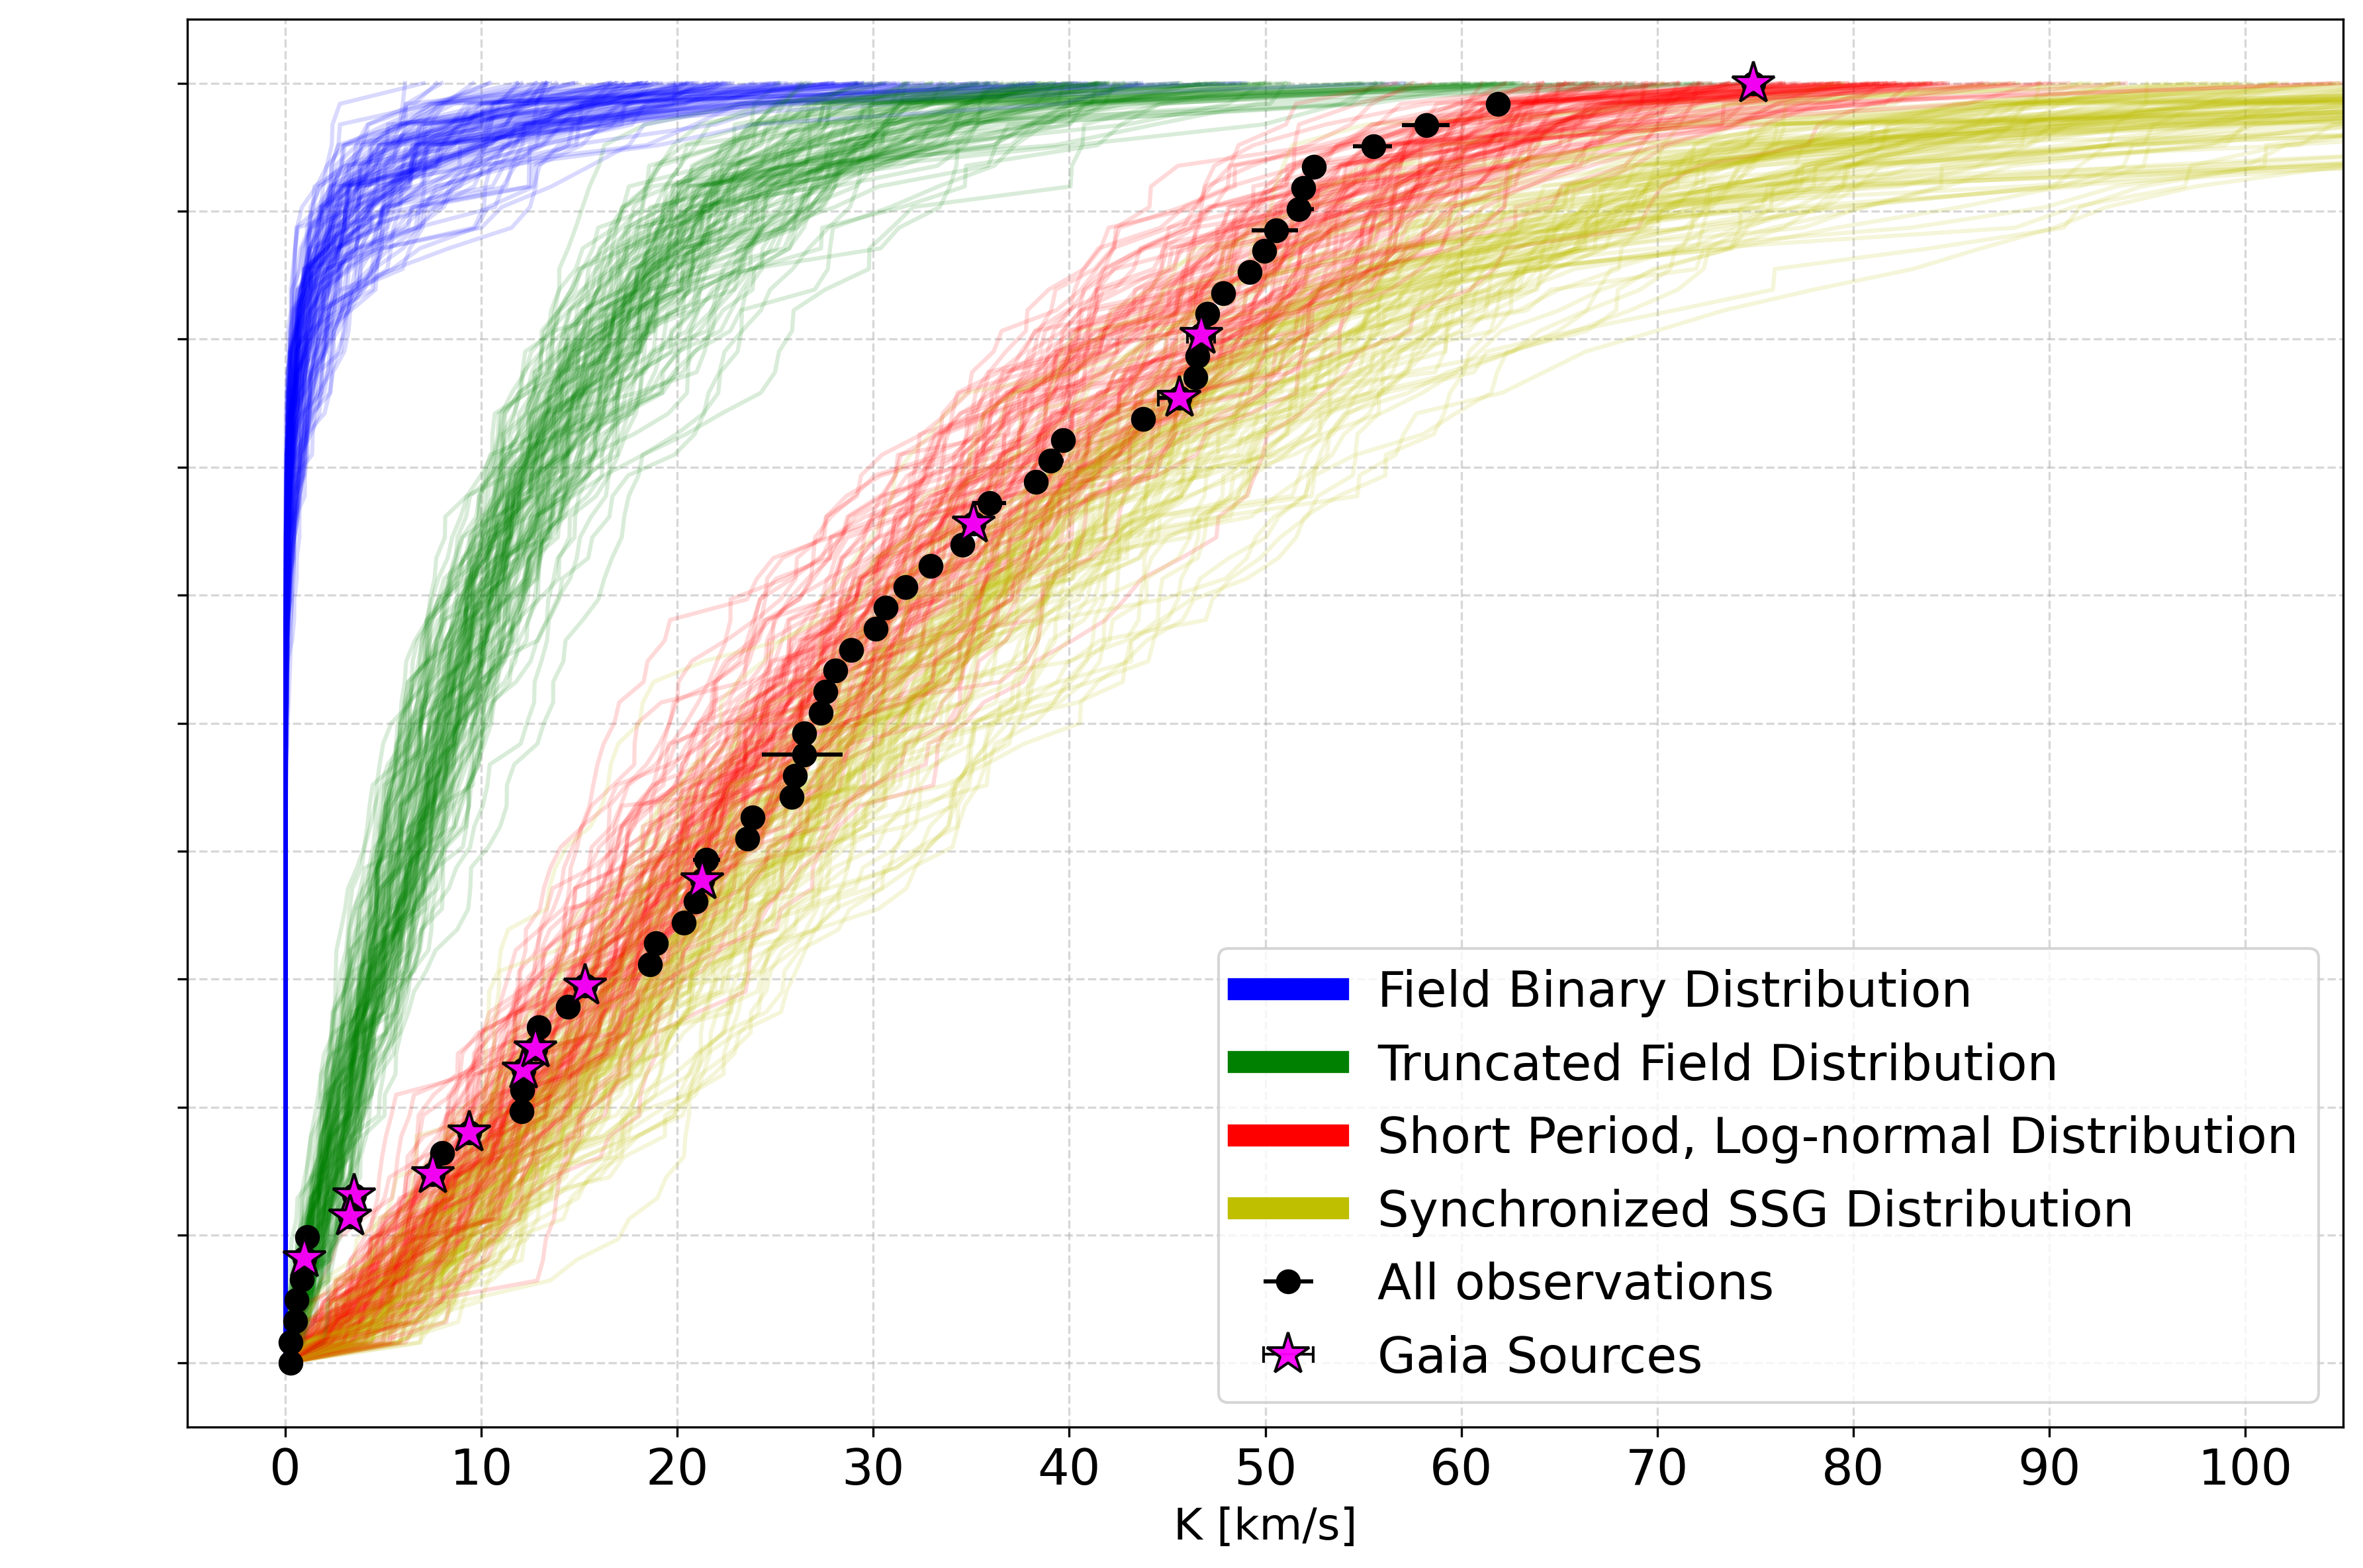

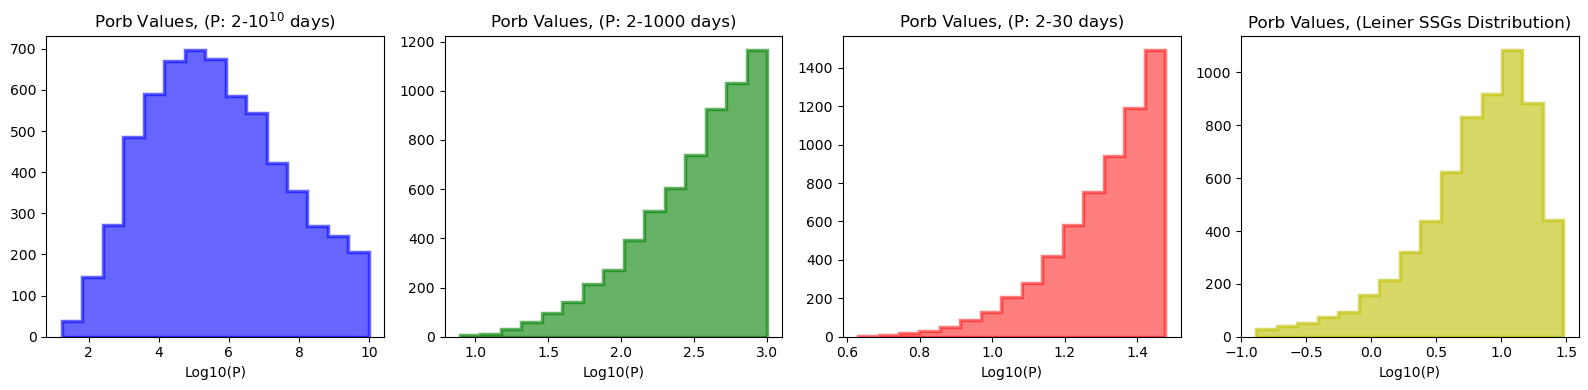

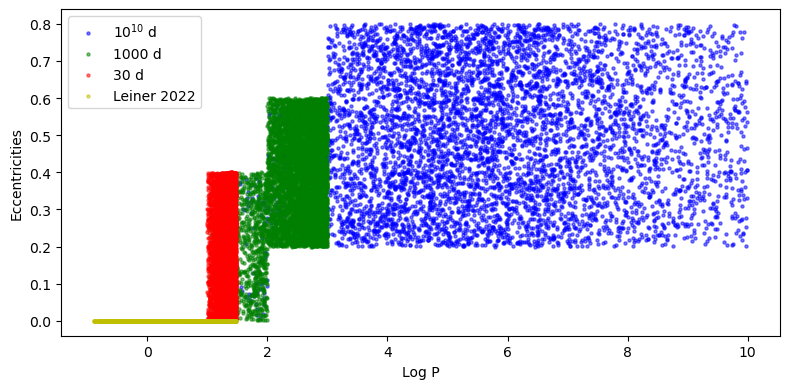

========== END OF LINE ==========


In [8]:
# =========================
# CDF plotter, with a bunch more options (from v1). 
# updated to include the different plotting methodology, and options for the plot type/identification
# =========================

from SamplingRVs_v2 import runsamples
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import os

numruns = 100            #Number of times we want to run the CDF generation -> multiple runs = multiple CDF distributions
numsamples = 62          #Number of samples for each simulated distribution
orbsamplerange = [3, 14] #Orbit sampling range - e.g, the orbits are observed between 3 and 14 times each (uniform random selection on this interval)
samplim = 3              #Lower bound for "good" data - e.g, sets the lower selected values for our data points.

#per-run options, keep these unchanged unless you want to see stats of individual iterations
displayCDF = True         #display each indivudaly CDF run (not advisable in this version)
displayElse = False       #shows each individual histogram/P-e plots
elseError = False         #show the KS test error
saveElse = False          #save each individual histogram/P-e plots

SaveFig = False                            #save each individual CDF run (not advisable in this code to set as true, so keep as False
PrintTest = False                          #print KS test values for each run
savefigname = "CDF_test"                   #name CDF(s). will automatically save the overall CDF
SAVE_DIR = "final_plots"                         #where to save the CDF
os.makedirs(SAVE_DIR, exist_ok=True)


RETURN_ELSE_DATA = True          # request logP/ec arrays from runsamples each run  (return the logP and eccentricity, necessary for plotting)
PLOT_ELSE_TOTAL  = True          # plot combined hist/scatter after all runs
SAVE_ELSE_TOTAL  = False         # save both distribution histograms and P-e plot
ELSE_SAVE_PREFIX = "CDF_else_plot"

# manual setting of the observed RVs (if desired). Needs to be in the same format as in SamplingRVs_2 (or the summary.txt)
# If None, SamplingRVs_v2.py uses its internal hard-coded data (default behavior).
# If you want to supply your own, set OBS_DATA = [...] with the same row format.
OBS_DATA = None #data_asym



# star-name labels next to obs points (only for OBS_GROUP="all")

LABEL_OBS_NAMES = False   #True/false, label all observations
LABEL_ONLY_GAIA = False   #True/false, label only the gaia stars
OBS_NAME_STYLE = {                # optional style overrides
    "fontsize": 8,
    "alpha": 0.95,
}
OBS_NAME_XYTEXT = (12, -6)          # text offset: (dx, dy)

mKSval_total, aKSval_total, mpval_total, apval_total = [], [], [], []

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

# show different levels 
SHOW_OBS          = True
SHOW_OBS_FULL     = True
SHOW_OBS_SAMPLIM  = False

# plot grouping
OBS_GROUP = "all"   # Options: "all", "ssg", "rs", "multi", "ssg_and_rs"


if OBS_GROUP == "ssg_and_rs":
    OBS_NAME_XYTEXT = (10, -2)  
    OBS_NAME_STYLE = {                #style overrides
        "fontsize": 6,
        "alpha": 0.95,
    }

SHOW_TRUE         = False    #show the 'true' RVs for each iteration
SHOW_MEASURED     = True     #show the 'measured' RVs for each iteration
SHOW_FILL         = False    #show the fill between 'true' and 'measured' for each iteration.

SIM_PLOT_STYLE = "line"
STEP_WHERE     = "mid"

LABEL_SIM = False          #label each individual iteration (clogs legend if more than just one run)
LABEL_OBS = True           #label 'mean' line, useful to keep as one plot device

# label certain stars
SHOW_SPEC_STARS = True  #when set to true, the labelled stars will be plotted
spec_stars_gaia = [                            #Gaia Stars
    "29Dra",
    "UCAC228842571",
    "2MASSJ17270871+2700144",
    "BMCVn",
    "FRBoo",
    "FVCnc",
    "HD113714",
    "HD161570",
    "HUVir",
    "2MASSJ08504952+1217158",
    "ROTSE1J184706.07+434032.7",
    "TYC3927-1130-1",
    "TYC4216-800-1",
    "TYC4428-785-1",
    "2MASSJ08171221+0736164",
    "V832Her",
    "V834Her",
    "V846Her",
]

spec_stars_unknown = [                         #Unknown stars
    "2MASSJ08504952+1217158", 
    "FVCnc",	
    "TYC3401-730-1", 
    "V503Hya",
    "V832Her",
    "V834Her",
    "V846Her", 
]

spec_stars_SB2 = [                             #SB2 stars
    '2MASSJ08504952+1217158',
    '54Cam',
    'FVCnc',
    'KNCnc',
    'OOBoo',
    'ROTSE1J135649.21+242927.1',
    'ROTSE1J160518.19+372623.5',
    'ROTSE1J170537.88+335052.5',
    'TYC1339-572-1',
    'TYC5003-138-1',
    'UCAC228842571',
    'V503Hya',
]
spec_stars = spec_stars_gaia    #choose which set of stars to label

SPEC_LABEL = "Gaia Sources"
SPEC_STYLE = None

#labelling stuff
agg = {
    "ecc_lognorm_2_1e10": {"actual": [], "measured": []},
    "ecc_lognorm_2_1000": {"actual": [], "measured": []},
    "ecc_lognorm_2_30":   {"actual": [], "measured": []},
    "tidal_locked":       {"actual": [], "measured": []},
}

#labelling stuff
else_agg = {
    "logPfullvals": [],
    "logP1000vals": [],
    "logPvals": [],
    "logPtidal": [],
    "ec_all": [],
}

for run in range(1, numruns + 1):
    plot_obs_this_run = (run == 1) and SHOW_OBS

    if RETURN_ELSE_DATA:
        mKSval, aKSval, mpval, apval, sim_data, else_data = runsamples(
            numsamples, orbsamplerange, samplim, run,
            dispCDF=displayCDF, dispElse=displayElse, elseerror=elseError, saveElse=saveElse,
            SaveThisFig=SaveFig, PrintTestResults=PrintTest, savefig_name=savefigname,
            ax=ax,

            plot_obs=plot_obs_this_run,
            plot_obs_full=SHOW_OBS_FULL,
            plot_obs_samplim=SHOW_OBS_SAMPLIM,
            obs_group=OBS_GROUP,   # "multi" plots all three; "ssg_and_rs" plots only those two

            # manual observation adjustment occurs here (set OBS_DATA earlier)
            obs_data=OBS_DATA,

            #  obs star-name labels (only for OBS_GROUP="all")
            label_obs_names=(LABEL_OBS_NAMES and plot_obs_this_run),
            obs_name_style=OBS_NAME_STYLE,
            obs_name_xytext=OBS_NAME_XYTEXT,
            obs_name_subset=(spec_stars if LABEL_ONLY_GAIA else None),

            # stars overlay
            plot_obs_spec=SHOW_SPEC_STARS and plot_obs_this_run,  # only draw once, like obs points
            spec_stars=spec_stars,
            spec_label=SPEC_LABEL,
            spec_style=SPEC_STYLE,
            warn_missing_spec=True,

            plot_true=SHOW_TRUE,
            plot_measured=SHOW_MEASURED,
            plot_fill=SHOW_FILL,
            sim_alpha=0.15,
            label_once=True,

            label_sim=LABEL_SIM,
            label_obs=LABEL_OBS,

            sim_plot_style=SIM_PLOT_STYLE,
            step_where=STEP_WHERE,

            return_sim_data=True,
            return_else_data=True
        )
    else:
        mKSval, aKSval, mpval, apval, sim_data = runsamples(
            numsamples, orbsamplerange, samplim, run,
            dispCDF=displayCDF, dispElse=displayElse, elseerror=elseError, saveElse=saveElse,
            SaveThisFig=SaveFig, PrintTestResults=PrintTest, savefig_name=savefigname,
            ax=ax,

            plot_obs=plot_obs_this_run,
            plot_obs_full=SHOW_OBS_FULL,
            plot_obs_samplim=SHOW_OBS_SAMPLIM,
            obs_group=OBS_GROUP,

            # manual observation adjustment occurs here (set OBS_DATA earlier)
            obs_data=OBS_DATA,

            #  obs star-name labels (only for OBS_GROUP="all")
            label_obs_names=(LABEL_OBS_NAMES and plot_obs_this_run),
            obs_name_style=OBS_NAME_STYLE,
            obs_name_xytext=OBS_NAME_XYTEXT,
            obs_name_subset=(spec_stars if LABEL_ONLY_GAIA else None),

            # stars overlay
            plot_obs_spec=SHOW_SPEC_STARS and plot_obs_this_run,
            spec_stars=spec_stars,
            spec_label=SPEC_LABEL,
            spec_style=SPEC_STYLE,
            warn_missing_spec=True,

            plot_true=SHOW_TRUE,
            plot_measured=SHOW_MEASURED,
            plot_fill=SHOW_FILL,
            sim_alpha=0.15,
            label_once=True,

            label_sim=LABEL_SIM,
            label_obs=LABEL_OBS,

            sim_plot_style=SIM_PLOT_STYLE,
            step_where=STEP_WHERE,

            return_sim_data=True
        )

    mKSval_total.append(mKSval)
    aKSval_total.append(aKSval)
    mpval_total.append(mpval)
    apval_total.append(apval)

    for k in agg.keys():
        agg[k]["actual"].append(sim_data[k]["actual"])
        agg[k]["measured"].append(sim_data[k]["measured"])

    # record 'else' arrays
    if RETURN_ELSE_DATA:
        for k in else_agg.keys():
            else_agg[k].append(else_data[k])


def cdf_xy(values: np.ndarray):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.array([0.0]), np.array([0.0])
    xs = np.sort(v)
    ys = np.arange(xs.size) / (xs.size - 1) if xs.size > 1 else np.array([1.0])
    xs = np.insert(xs, 0, 0.0)
    ys = np.insert(ys, 0, 0.0)
    return xs, ys * 100.0


def draw_curve(ax, xs, ys, *, color, label, style="line", where="mid",
               lw=4.5, alpha=1.0, zorder=100):
    if style == "step":                #if you want to take the full distribution labels out, comment out label=label for both
        ax.step(xs, ys, where=where, color=color, linewidth=lw, alpha=alpha, zorder=zorder, label=label) 
    else:
        ax.plot(xs, ys, color=color, linewidth=lw, linestyle="-", alpha=alpha, zorder=zorder, label=label)


#labels for each distribution
labels_colors = {
    "ecc_lognorm_2_1e10": (r'Field Binary Distribution', "blue"),
    "ecc_lognorm_2_1000": ('Truncated Field Distribution', "green"),
    "ecc_lognorm_2_30":   ('Short Period, Log-normal Distribution', "red"),
    "tidal_locked":       ('Synchronized SSG Distribution', "y"),
}


#this creates a 'mean' curve, which we decided against using. I use it for the Legend, so that I don't overcomplicate the labelling (and so the color is darker)
for key, (lbl, col) in labels_colors.items():
    all_meas = np.concatenate(agg[key]["measured"]) if len(agg[key]["measured"]) else np.array([])
    xs, ys = cdf_xy(all_meas)

    draw_curve(
        ax, xs + 150, ys,      #move the 'mean' line off the image so it's not seen, but still plotted 
        color=col,
        label=lbl,
        style=SIM_PLOT_STYLE,
        where=STEP_WHERE,
        lw=8,
        alpha=1.00,
        zorder=98
    )

ax.set_xlabel("K [km/s]", fontsize=16)
ax.set_ylabel("Probability [%]", fontsize=16, color = 'white')

ax.tick_params(axis='both', which='major', labelsize=18)
ax.tick_params(axis='both', which='minor', labelsize=18)
ax.set_xticks(np.arange(0, 105, 10))
ax.set_yticks(np.arange(0, 105, 10))

ax.set_xlim(-5, 105)
ax.set_ylim(-5, 105)

ax.grid(alpha=0.5, linestyle="--")

#ax.set_ylabel("")                           # remove axis label
#ax.tick_params(axis='y', labelleft=False)   # remove tick numbers only
ax.tick_params(axis='y', labelcolor='white')


ax.legend(loc="lower right", fontsize=18)  #changed between 18 and 26

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, f"{savefigname}.png"), dpi=300)
plt.show()


# plot period distributions and eccentricities
if RETURN_ELSE_DATA and PLOT_ELSE_TOTAL:
    logPfull_all  = np.concatenate(else_agg["logPfullvals"])  if len(else_agg["logPfullvals"])  else np.array([])
    logP1000_all  = np.concatenate(else_agg["logP1000vals"])  if len(else_agg["logP1000vals"])  else np.array([])
    logP30_all    = np.concatenate(else_agg["logPvals"])      if len(else_agg["logPvals"])      else np.array([])
    logPtidal_all = np.concatenate(else_agg["logPtidal"])     if len(else_agg["logPtidal"])     else np.array([])
    ec_all        = np.concatenate(else_agg["ec_all"], axis=0) if len(else_agg["ec_all"]) else np.empty((0, 4))

    # period distribution histograms
    fig2, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].hist(logPfull_all, 15, histtype='stepfilled',
                 facecolor='b', edgecolor='b', alpha=0.6, linewidth=2.5)
    axes[0].set_title(r"Porb Values, (P: 2-$10^{10}$ days)")
    axes[0].set_xlabel("Log10(P)")

    axes[1].hist(logP1000_all, 15, histtype='stepfilled',
                 facecolor='g', edgecolor='g', alpha=0.6, linewidth=2.5)
    axes[1].set_title("Porb Values, (P: 2-1000 days)")
    axes[1].set_xlabel("Log10(P)")

    axes[2].hist(logP30_all, 15, histtype='stepfilled',
                 facecolor='r', edgecolor='r', alpha=0.5, linewidth=2.5)
    axes[2].set_title("Porb Values, (P: 2-30 days)")
    axes[2].set_xlabel("Log10(P)")

    axes[3].hist(logPtidal_all, 15, histtype='stepfilled',
                 facecolor='y', edgecolor='y', alpha=0.6, linewidth=2.5)
    axes[3].set_title("Porb Values, (Leiner SSGs Distribution)")
    axes[3].set_xlabel("Log10(P)")

    plt.tight_layout()
    if SAVE_ELSE_TOTAL:
        plt.savefig(f"{ELSE_SAVE_PREFIX}_Distributions.png", dpi=300)
    plt.show()
    plt.close(fig2)

    # eccentricities plot
    fig3, ax3 = plt.subplots(figsize=(8, 4))

    # ec_all columns are [einfe, e2e, e1e, e3] per your code
    if ec_all.shape[0] > 0:
        ax3.scatter(logPfull_all,  ec_all[:, 0], label=r"$10^{10}$ d", color='b', alpha=0.5, s=5)
        ax3.scatter(logP1000_all,  ec_all[:, 1], label='1000 d',       color='g', alpha=0.5, s=5)
        ax3.scatter(logP30_all,    ec_all[:, 2], label='30 d',         color='r', alpha=0.5, s=5)
        ax3.scatter(logPtidal_all, ec_all[:, 3], label='Leiner 2022',  color='y', alpha=0.5, s=5)

    ax3.legend()
    ax3.set_xlabel("Log P")
    ax3.set_ylabel("Eccentricities")

    plt.tight_layout()
    if SAVE_ELSE_TOTAL:
        plt.savefig(f"{ELSE_SAVE_PREFIX}_Eccentricities.png", dpi=300)
    plt.show()
    plt.close(fig3)


print('========== END OF LINE ==========')

In [3]:
#Manual adjustment data
#this is our asymmetric SB2 fit data
nan = np.nan
data_asym =         [
        ['29Dra', 5, 0.992, 0.151, 0.167, nan, nan, nan, 'SSG', 'SB1'],
        ['2MASSJ08171221+0736164', 4, 12.751, 0.193, 0.153, nan, nan, nan, 'RS', 'SB1'],
        #['2MASSJ08504952+1217158', 4, 18.098, 0.324, 0.380, 4.965, 0.369, 0.565, '--', 'SB2'],
        ['2MASSJ17270871+2700144', 3, 3.493, 0.051, 0.045, nan, nan, nan, 'SSG', 'SB1'],
        ['54Cam', 5, 49.191, 0.157, 0.155, 48.586, 0.248, 0.225, 'RS', 'SB2'],
        ['ASASJ073642+0354.3', 8, 0.576, 0.108, 0.091, nan, nan, nan, 'SSG', 'SB1'],
        ['ASASJ155307+2028.6', 4, 47.053, 0.211, 0.258, nan, nan, nan, 'SSG', 'SB1'],
        ['ASASJ162510+0514.9', 9, 67.998, 5.394, 3.434, 37.858, 7.865, 4.184, 'SSG', 'Asymmetric'],    #NEW
        ['ASASJ210323+1930.9', 12, 28.870, 0.344, 0.367, nan, nan, nan, 'SSG', 'SB1'],
        ['BD+142519', 7, 47.688, 0.674, 0.755, 27.563, 0.782, 0.901, 'SSG', 'Asymmetric'],     #NEW
        ['BD+201895', 3, 8.755, 0.225, 0.203, 10.505, 0.274, 0.288, 'RS', 'Asymmetric'],       #NEW
        ['BMCVn', 7, 12.139, 0.136, 0.153, nan, nan, nan, 'SSG', 'SB1'],
        ['BPSCS22950-0027', 12, 26.011, 0.153, 0.150, nan, nan, nan, 'SSG', 'SB1'],
        ['CGTri', 12, 61.635, 3.206, 18.519, 48.988, 6.883, 31.081, 'SSG', 'Asymmetric'],     #NEW
        ['EPCVn', 12, 49.956, 0.106, 0.117, nan, nan, nan, 'SSG', 'SB1'],
        ['FMLyn', 6, 31.651, 0.287, 0.290, nan, nan, nan, 'RS', 'SB1'],
        ['FNCom', 13, 44.937, 1.393, 1.066, 45.832, 2.145, 1.734, 'SSG', 'Asymmetric'],     #NEW
        ['FRBoo', 9, 3.316, 0.161, 0.156, nan, nan, nan, 'RS', 'SB1'],
        #['FVCnc', 4, 27.034, 0.077, 0.069, 28.581, 0.118, 0.126, '--', 'SB2'],
        ['GSC00563-00384', 10, 14.422, 0.107, 0.125, nan, nan, nan, 'SSG', 'SB1'],
        ['GSC02769-00149', 11, 28.684, 0.429, 0.799, 16.784, 1.083, 1.940, 'SSG', 'Asymmetric'],     #NEW
        ['HD113714', 5, 74.895, 0.248, 0.246, nan, nan, nan, 'RS', 'SB1'],
        ['HD161570', 6, 21.266, 0.061, 0.062, nan, nan, nan, 'RS', 'SB1'],
        ['HD347929', 13, 0.853, 0.132, 0.142, nan, nan, nan, 'SSG', 'SB1'],
        ['HD53476', 4, 20.336, 0.152, 0.135, nan, nan, nan, 'RS', 'SB1'],
        ['HRPsc', 12, 23.317, 2.111, 1.897, 31.037, 2.689, 2.875, 'SSG', 'Asymmetric'],     #NEW
        ['HUVir', 12, 51.767, 1.224, 1.459, 44.232, 1.578, 1.868, 'SSG', 'Asymmetric'],     #NEW
        ['KLCnc', 5, 1.224, 1.334, 0.498, 44.323, 1.770, 1.837, 'SSG', 'Asymmetric'],     #NEW
        ['KNCnc', 9, 27.324, 0.153, 0.160, 6.229, 0.319, 0.273, 'SSG', 'SB2'],
        ['KYBoo', 10, 0.510, 0.184, 0.205, nan, nan, nan, 'SSG', 'SB1'],
        ['MPBoo', 5, 0.276, 0.079, 0.079, nan, nan, nan, 'RS', 'SB1'],
        ['MSBoo', 5, 18.595, 0.140, 0.199, nan, nan, nan, 'SSG', 'SB1'],
        ['MXBoo', 4, 0.262, 0.108, 0.111, nan, nan, nan, 'RS', 'SB1'],
        ['MXDra', 9, 49.260, 0.673, 12.646, 37.932, 14.477, 3.285, 'SSG', 'Asymmetric'],     #NEW
        ['NPCom', 6, 61.883, 0.431, 0.413, nan, nan, nan, 'SSG', 'SB1'],
        ['NRLib', 8, 48.808, 2.253, 1.901, 45.536, 3.085, 2.810, 'SSG', 'Asymmetric'],     #NEW
        ['OOBoo', 4, 30.136, 0.137, 0.117, 22.988, 0.377, 0.340, 'RS', 'SB2'],
        ['QZBoo', 12, 32.924, 0.146, 0.190, nan, nan, nan, 'SSG', 'SB1'],
        ['ROTSE1J135649.21+242927.1', 6, 23.842, 0.109, 0.092, 2.318, 0.113, 0.118, 'RS', 'SB2'],
        ['ROTSE1J160518.19+372623.5', 4, 46.531, 0.138, 0.132, 45.682, 0.348, 0.369, 'SSG', 'SB2'],
        ['ROTSE1J162157.22+381733.6', 4, 27.572, 0.103, 0.099, nan, nan, nan, 'RS', 'SB1'],
        ['ROTSE1J170537.88+335052.5', 4, 20.952, 0.274, 0.282, 16.809, 1.050, 0.991, 'RS', 'SB2'],
        ['ROTSE1J172404.95+182937.3', 3, 18.915, 0.155, 0.160, nan, nan, nan, 'SSG', 'SB1'],
        ['ROTSE1J183703.58+280017.1', 5, 19.354, 0.370, 0.374, 15.895, 0.691, 0.687, 'RS', 'Asymmetric'],     #NEW
        ['ROTSE1J184706.07+434032.7', 5, 7.540, 0.127, 0.137, nan, nan, nan, 'SSG', 'SB1'],
        ['RXJ1112.4+3950', 15, 66.561, 21.822, 28.110, 78.784, 24.441, 5.493, 'SSG', 'Asymmetric'],     #NEW
        ['TYC1339-572-1', 4, 12.046, 0.169, 0.178, 8.673, 0.131, 0.121, 'SSG', 'SB2'],
        ['TYC1543-131-1', 3, 7.990, 0.086, 0.088, nan, nan, nan, 'RS', 'SB1'],
        ['TYC2268-394-1', 11, 58.238, 1.174, 1.262, nan, nan, nan, 'SSG', 'SB1'],
        ['TYC2645-156-1', 6, 29.514, 3.405, 1.027, 38.149, 1.023, 12.556, 'RS', 'Asymmetric'],     #NEW
        #['TYC3401-730-1', 3, 62.355, 1.527, 1.685, nan, nan, nan, '--', 'SB1'],
        ['TYC3557-919-1', 10, 26.490, 0.129, 0.127, nan, nan, nan, 'SSG', 'SB1'],
        ['TYC3927-1130-1', 5, 35.127, 0.386, 0.328, nan, nan, nan, 'RS', 'SB1'],
        ['TYC4216-800-1', 5, 15.280, 0.145, 0.116, nan, nan, nan, 'RS', 'SB1'],
        ['TYC4223-399-1', 23, 26.459, 1.976, 2.145, nan, nan, nan, 'SSG', 'SB1'],
        ['TYC4415-328-1', 10, 12.916, 0.154, 0.212, nan, nan, nan, 'SSG', 'SB1'],
        ['TYC4422-1970-1', 18, 38.306, 0.552, 0.511, nan, nan, nan, 'RS', 'SB1'],
        ['TYC4428-785-1', 3, 9.378, 0.106, 0.091, nan, nan, nan, 'RS', 'SB1'],
        ['TYC4667-90-1', 11, 52.809, 10.861, 6.484, 53.434, 21.450, 18.761, 'SSG', 'Asymmetric'],     #NEW
        ['TYC5003-138-1', 8, 46.438, 0.246, 0.288, 60.411, 0.286, 0.297, 'SSG', 'SB2'],
        ['TYC583-566-1', 11, 51.934, 0.516, 0.503, nan, nan, nan, 'SSG', 'SB1'],
        ['UCAC228842571', 35, 45.614, 0.509, 1.075, 46.522, 7.848, 17.727, 'SSG', 'SB2'],
        ['V424Gem', 4, 28.076, 0.091, 0.106, nan, nan, nan, 'SSG', 'SB1'],
        ['V457Vir', 6, 38.853, 12.453, 2.586, 59.080, 31.122, 1.397, 'RS', 'Asymmetric'],     #NEW
        ['V498And', 11, 30.630, 0.280, 0.373, nan, nan, nan, 'SSG', 'SB1'],
        #['V503Hya', 5, 70.636, 0.647, 0.578, 54.455, 0.904, 0.902, '--', 'SB2'],
        #['V832Her', 5, 10.286, 0.059, 0.058, nan, nan, nan, '--', 'SB1'],
        #['V834Her', 7, 1.159, 0.165, 0.194, nan, nan, nan, '--', 'SB1'],
        #['V846Her', 5, 17.532, 0.206, 0.262, nan, nan, nan, '--', 'SB1']
]

#data_asym


len(data_asym)
sum = 0
sb1, sb2, asym = 0,0,0
ssg, rs = 0,0
cut = 0
for i in range(len(data_asym)):
    sum = sum+ data_asym[i][1]
    if data_asym[i][9] == "SB1":
        sb1 = sb1+1
    if data_asym[i][9] == "SB2":
        sb2 = sb2+1
    if data_asym[i][9] == "Asymmetric":
        asym = asym+1

    if data_asym[i][8] == "SSG":
        ssg = ssg+1
    if data_asym[i][8] == "RS":
        rs = rs+1
    if data_asym[i][8] == "--":
        cut = cut+1


#sum, sb1, sb2, asym, (sb1+sb2+asym), ssg, rs, cut


print(f"""===================
Total Observations: {sum}
===================
SB1:    {sb1}
SB2:    {sb2}
Asym:   {asym}
Total:  {sb1+sb2+asym}
===================
SSG:    {ssg}
RS:     {rs}
Cut:    {cut}
""")

Total Observations: 511
SB1:    37
SB2:    9
Asym:   16
Total:  62
SSG:    40
RS:     22
Cut:    0



In [7]:

# KS summaries 

import pandas as pd
import numpy as np
from IPython.display import display 


# output toggles (set True/False as desired)
PRINT_F = True          # print Full (F-*) scenarios?
PRINT_L = False         # print Limited (L-*) scenarios?

PRINT_OBS_KS = True     # "Observed KS" table
PRINT_EXP_KS = False    # "Expected KS" table
PRINT_OBS_P  = True     # "Observed p"  table
PRINT_EXP_P  = False    # "Expected p"  table

SHOW_MEAN_STD = True    # include "Mean +/- Std"
SHOW_MEAN     = False   # include "Mean"
SHOW_STD      = False   # include "Std"
SHOW_MEDIAN   = False   # include "Median"

DECIMALS = 4            # formatting decimals in table

# Table orientation toggle
#   "horizontal": scenarios are columns, metrics are rows
#   "vertical":   scenarios are rows, metrics are columns
TABLE_ORIENTATION = "vertical"   # "horizontal" or "vertical"

# Optional exports
SAVE_RAW_CSV     = False
SAVE_TABLES_CSV  = False
RAW_CSV_NAME     = "ks_raw_by_run.csv"
TABLE_PREFIX     = "ks_summary"   # files like ks_summary_obs_ks.csv


# -------------------------
# Scenario labels
# [F-10^4, F-1000, F-30, F-TL, L-∞, L-1000, L-30, L-TL]   
# F = full
# TL = tidally locked
# numbers = period upper limit (10^4 days, 1000 day, 30 day
# L = limited comparison - not used in our final paper
# -------------------------
scenario_labels = {
    0: r"$F\!-\!10^{10}$",
    1: r"$F\!-\!1000$",
    2: r"$F\!-\!30$",
    3: r"$F\!-\!TL$",
    4: r"$L\!-\!10^{10}$",
    5: r"$L\!-\!1000$",
    6: r"$L\!-\!30$",
    7: r"$L\!-\!TL$",
}

# -------------------------
# Build scenario order based on F/L toggles
# -------------------------
scenario_order = []
if PRINT_F:
    scenario_order += [
        r"$F\!-\!10^{10}$",
        r"$F\!-\!1000$",
        r"$F\!-\!30$",
        r"$F\!-\!TL$",
    ]
if PRINT_L:
    scenario_order += [
        r"$L\!-\!10^{10}$",
        r"$L\!-\!1000$",
        r"$L\!-\!30$",
        r"$L\!-\!TL$",
    ]

if len(scenario_order) == 0:
    raise ValueError("At least one of PRINT_F or PRINT_L must be True.")

TABLE_ORIENTATION = str(TABLE_ORIENTATION).lower().strip()
if TABLE_ORIENTATION not in ("horizontal", "vertical"):
    raise ValueError("TABLE_ORIENTATION must be 'horizontal' or 'vertical'.")


# -------------------------
# Build raw results dataframe: one row per (run, scenario, comp, stat)
# Requires these to already exist from the main loop:
#   numruns, mKSval_total, aKSval_total, mpval_total, apval_total
# -------------------------
records = []
for r in range(numruns):
    run_num = r + 1
    mKS = mKSval_total[r]
    aKS = aKSval_total[r]
    mp  = mpval_total[r]
    ap  = apval_total[r]

    for k in range(8):
        scen = scenario_labels[k]
        records.append((run_num, scen, "Observed", "KS", float(mKS[k])))
        records.append((run_num, scen, "Observed", "p",  float(mp[k])))
        records.append((run_num, scen, "Expected", "KS", float(aKS[k])))
        records.append((run_num, scen, "Expected", "p",  float(ap[k])))

df = pd.DataFrame(records, columns=["run", "scenario", "comp", "stat", "value"])

if SAVE_RAW_CSV:
    df.to_csv(RAW_CSV_NAME, index=False)


# -------------------------
# Summary builder
# -------------------------
def summarize_across_runs_table(
    df_raw: pd.DataFrame,
    comp: str,
    stat: str,
    scenario_order,
    decimals=4,
    show_mean_std=True,
    show_mean=False,
    show_std=False,
    show_median=False,
    orientation="horizontal"
) -> pd.DataFrame:
    """
    Summarize across runs for a single iteration.

    orientation="horizontal":
        columns -> scenarios
        rows    -> metrics
    orientation="vertical":
        rows    -> scenarios
        columns -> metrics
    """

    sub = df_raw[(df_raw["comp"] == comp) & (df_raw["stat"] == stat)].copy()
    g = sub.groupby("scenario")["value"]

    means = g.mean().reindex(scenario_order)
    stds  = g.std(ddof=1).reindex(scenario_order)
    meds  = g.median().reindex(scenario_order)

    metrics = {}

    if show_mean_std:
        metrics["Mean ± Std"] = [
            f"{means[s]:.{decimals}f} ± {0.0 if pd.isnull(stds[s]) else stds[s]:.{decimals}f}"
            for s in scenario_order
        ]
    if show_mean:
        metrics["Mean"] = [f"{means[s]:.{decimals}f}" for s in scenario_order]
    if show_std:
        metrics["Std"] = [f"{0.0 if pd.isnull(stds[s]) else stds[s]:.{decimals}f}" for s in scenario_order]
    if show_median:
        metrics["Median"] = [f"{meds[s]:.{decimals}f}" for s in scenario_order]

    if orientation == "horizontal":
        # metrics are rows, scenarios are columns
        table = pd.DataFrame(metrics, index=scenario_order).T
        table.index.name = f"{comp} {stat}"
        return table

    # orientation == "vertical"
    # scenarios are rows, metrics are columns
    table = pd.DataFrame(metrics, index=scenario_order)
    table.index.name = "Scenario"
    table.columns.name = f"{comp} {stat}"
    return table


def build_and_maybe_print_table(comp: str, stat: str, title: str, filename_stub: str):
    tbl = summarize_across_runs_table(
        df,
        comp=comp,
        stat=stat,
        scenario_order=scenario_order,
        decimals=DECIMALS,
        show_mean_std=SHOW_MEAN_STD,
        show_mean=SHOW_MEAN,
        show_std=SHOW_STD,
        show_median=SHOW_MEDIAN,
        orientation=TABLE_ORIENTATION
    )

    print(f"\n{title}  [orientation: {TABLE_ORIENTATION}]")
    display(tbl)  # <-- NEW: Jupyter renders LaTeX in headers/index

    if SAVE_TABLES_CSV:
        tbl.to_csv(f"{TABLE_PREFIX}_{filename_stub}.csv")

    return tbl


pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

# -------------------------
# Print selected outputs
# -------------------------
print("All values computed across runs")
tables = {}

if PRINT_OBS_KS:
    tables["obs_ks"] = build_and_maybe_print_table(
        comp="Observed", stat="KS",
        title="Observed KS (across runs)",
        filename_stub="obs_ks"
    )

if PRINT_EXP_KS:
    tables["exp_ks"] = build_and_maybe_print_table(
        comp="Expected", stat="KS",
        title="Expected KS (across runs)",
        filename_stub="exp_ks"
    )

if PRINT_OBS_P:
    tables["obs_p"] = build_and_maybe_print_table(
        comp="Observed", stat="p",
        title="Observed p (across runs)",
        filename_stub="obs_p"
    )

if PRINT_EXP_P:
    tables["exp_p"] = build_and_maybe_print_table(
        comp="Expected", stat="p",
        title="Expected p (across runs)",
        filename_stub="exp_p"
    )

print("========== End of Line ==========")


All values computed across runs

Observed KS (across runs)  [orientation: vertical]


Observed KS,Mean ± Std
Scenario,
$F\!-\!10^{10}$,0.8040 ± 0.0269
$F\!-\!1000$,0.5339 ± 0.0424
$F\!-\!30$,0.1419 ± 0.0260
$F\!-\!TL$,0.1594 ± 0.0381



Observed p (across runs)  [orientation: vertical]


Observed p,Mean ± Std
Scenario,
$F\!-\!10^{10}$,0.0000 ± 0.0000
$F\!-\!1000$,0.0000 ± 0.0000
$F\!-\!30$,0.5800 ± 0.1998
$F\!-\!TL$,0.4669 ± 0.2374


========== End of Line ==========
